# **Data Preprocessing**

In [1]:
# Cargar datos de excel
import pandas as pd
import numpy as np
from pathlib import Path
data_22june2020_1 = pd.read_excel('SWaT.A7_June 2020/22June2020 (1).xlsx')
data_22june2020_2 = pd.read_excel('SWaT.A7_June 2020/22June2020 (2).xlsx')
data_29june2020_1 = pd.read_excel('SWaT.A7_June 2020/29June2020 (1).xlsx')
data_29june2020_2 = pd.read_excel('SWaT.A7_June 2020/29June2020 (2).xlsx')

# ----------------------------
# 1. Cargar archivos originales
# ----------------------------
files = {
    "22June2020_1": data_22june2020_1.copy(),
    "22June2020_2": data_22june2020_2.copy(),
    "29June2020_1": data_29june2020_1.copy(),
    "29June2020_2": data_29june2020_2.copy(),
}

# ----------------------------
# 2. Hallar columnas comunes
# ----------------------------
common_cols = sorted(set.intersection(*(set(df.columns) for df in files.values())))
print(f"Número de columnas comunes: {len(common_cols)}")

# Verificar cuáles quedaron fuera:
for name, df in files.items():
    extra = sorted(set(df.columns) - set(common_cols))
    if extra:
        print(f"{name} tiene columnas no comunes: {extra}")

# ----------------------------
# 3. Mantener solo columnas comunes y mismo orden
# ----------------------------
files = {name: df[common_cols].copy() for name, df in files.items()}

# ----------------------------
# 4. Función de limpieza básica
# ----------------------------
def clean_swat_df(df):
    df = df.copy()

    # Reemplazar valores inválidos
    df = df.replace("Bad Input", pd.NA)

    # ------------------------
    # Timestamp
    # ------------------------
    if "t_stamp" in df.columns:
        df["t_stamp"] = (
            df["t_stamp"]
            .astype(str)
            .str.replace("/yy ", "/2020 ", regex=False)
            .str.strip()
        )
        df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")

    # ------------------------
    # Variables continuas
    # ------------------------
    pv_cols = [c for c in df.columns if c.endswith(".Pv")]
    df[pv_cols] = df[pv_cols].apply(pd.to_numeric, errors="coerce")

    # ------------------------
    # Variables discretas
    # ------------------------
    status_cols = [c for c in df.columns if c.endswith(".Status")]
    state_cols = [c for c in df.columns if c.startswith("P") and c.endswith("_STATE")]

    df[status_cols + state_cols] = (
        df[status_cols + state_cols]
        .apply(pd.to_numeric, errors="coerce")
        .astype("Int64")  # entero con NaN permitido
    )

    return df

# ----------------------------
# 5. Aplicar limpieza
# ----------------------------
files_clean = {name: clean_swat_df(df) for name, df in files.items()}

# ----------------------------
# 6. Guardar
# ----------------------------
output_dir = Path("SWaT.A7_June2020_clean")
output_dir.mkdir(parents=True, exist_ok=True)

for name, df in files_clean.items():
    df.to_csv(output_dir / f"{name}.csv", index=False)

print("Archivos limpios guardados.")

Número de columnas comunes: 61
22June2020_1 tiene columnas no comunes: ['AIT301.Pv', 'AIT302.Pv', 'AIT303.Pv', 'DPSH301.Alarm', 'LS201.Alarm', 'LS202.Alarm', 'LS401.Alarm', 'LSH601.Alarm', 'LSH602.Alarm', 'LSH603.Alarm', 'LSL203.Alarm', 'LSL601.Alarm', 'LSL602.Alarm', 'LSL603.Alarm', 'LSLL203.Alarm', 'P207.Status', 'P208.Status', 'P603.Status', 'PSH301.Alarm', 'PSH501.Alarm', 'PSL501.Alarm']
22June2020_2 tiene columnas no comunes: ['AIT301.Pv', 'AIT302.Pv', 'AIT303.Pv', 'DPSH301.Alarm', 'LS201.Alarm', 'LS202.Alarm', 'LS401.Alarm', 'LSH601.Alarm', 'LSH602.Alarm', 'LSH603.Alarm', 'LSL203.Alarm', 'LSL601.Alarm', 'LSL602.Alarm', 'LSL603.Alarm', 'LSLL203.Alarm', 'P207.Status', 'P208.Status', 'P603.Status', 'PSH301.Alarm', 'PSH501.Alarm', 'PSL501.Alarm']
29June2020_1 tiene columnas no comunes: ['Unnamed: 100', 'Unnamed: 1000', 'Unnamed: 10000', 'Unnamed: 10001', 'Unnamed: 10002', 'Unnamed: 10003', 'Unnamed: 10004', 'Unnamed: 10005', 'Unnamed: 10006', 'Unnamed: 10007', 'Unnamed: 10008', 'Unna

## Identificar variables

In [2]:
# ============================
# Identificación automática de variables
# ============================

# Tomamos un dataframe de referencia, ya limpio y con columnas homologadas
sample_df = next(iter(files_clean.values()))

all_cols = sample_df.columns.tolist()

# Timestamp
timestamp_cols = [c for c in all_cols if c == "t_stamp"]

# Sensores continuos
pv_cols = [c for c in all_cols if c.endswith(".Pv")]

# Actuadores / estados discretos
status_cols = [c for c in all_cols if c.endswith(".Status")]
state_cols = [c for c in all_cols if c.startswith("P") and c.endswith("_STATE")]

# Otras columnas que no entraron en ninguna categoría
classified_cols = set(timestamp_cols + pv_cols + status_cols + state_cols)
other_cols = [c for c in all_cols if c not in classified_cols]

print("Resumen de variables detectadas")
print(f"Timestamp: {len(timestamp_cols)}")
print(f"Sensores continuos (.Pv): {len(pv_cols)}")
print(f"Actuadores discretos (.Status): {len(status_cols)}")
print(f"Estados discretos (_STATE): {len(state_cols)}")
print(f"Otras columnas no clasificadas: {len(other_cols)}")

if timestamp_cols:
    print("\nTimestamp:")
    print(timestamp_cols)

if other_cols:
    print("\nColumnas no clasificadas:")
    print(other_cols)

Resumen de variables detectadas
Timestamp: 1
Sensores continuos (.Pv): 25
Actuadores discretos (.Status): 29
Estados discretos (_STATE): 6
Otras columnas no clasificadas: 0

Timestamp:
['t_stamp']


In [3]:
print("\n--- Sensores continuos (.Pv) ---")
print(pv_cols)

print("\n--- Actuadores discretos (.Status) ---")
print(status_cols)

print("\n--- Estados discretos (_STATE) ---")
print(state_cols)


--- Sensores continuos (.Pv) ---
['AIT201.Pv', 'AIT202.Pv', 'AIT203.Pv', 'AIT401.Pv', 'AIT402.Pv', 'AIT501.Pv', 'AIT502.Pv', 'AIT503.Pv', 'AIT504.Pv', 'DPIT301.Pv', 'FIT101.Pv', 'FIT201.Pv', 'FIT301.Pv', 'FIT401.Pv', 'FIT501.Pv', 'FIT502.Pv', 'FIT503.Pv', 'FIT504.Pv', 'FIT601.Pv', 'LIT101.Pv', 'LIT301.Pv', 'LIT401.Pv', 'PIT501.Pv', 'PIT502.Pv', 'PIT503.Pv']

--- Actuadores discretos (.Status) ---
['MV101.Status', 'MV201.Status', 'MV301.Status', 'MV302.Status', 'MV303.Status', 'MV304.Status', 'MV501.Status', 'MV502.Status', 'MV503.Status', 'MV504.Status', 'P101.Status', 'P102.Status', 'P201.Status', 'P202.Status', 'P203.Status', 'P204.Status', 'P205.Status', 'P206.Status', 'P301.Status', 'P302.Status', 'P401.Status', 'P402.Status', 'P403.Status', 'P404.Status', 'P501.Status', 'P502.Status', 'P601.Status', 'P602.Status', 'UV401.Status']

--- Estados discretos (_STATE) ---
['P1_STATE', 'P2_STATE', 'P3_STATE', 'P4_STATE', 'P5_STATE', 'P6_STATE']


In [4]:
# Features que sí entran al modelo
feature_cols = pv_cols + status_cols + state_cols

print(f"Total de features para el modelo: {len(feature_cols)}")
print(feature_cols[:10], "..." if len(feature_cols) > 10 else "")

Total de features para el modelo: 60
['AIT201.Pv', 'AIT202.Pv', 'AIT203.Pv', 'AIT401.Pv', 'AIT402.Pv', 'AIT501.Pv', 'AIT502.Pv', 'AIT503.Pv', 'AIT504.Pv', 'DPIT301.Pv'] ...


In [5]:
continuous_cols = pv_cols
discrete_cols = status_cols + state_cols

print(f"Variables continuas a escalar: {len(continuous_cols)}")
print(f"Variables discretas sin escalar: {len(discrete_cols)}")

Variables continuas a escalar: 25
Variables discretas sin escalar: 35


## Perfilamiento

In [6]:
summary_rows = []

for name, df in files_clean.items():
    summary_rows.append({
        "file": name,
        "rows": len(df),
        "cols": len(df.columns),
        "start_time": df["t_stamp"].min() if "t_stamp" in df.columns else None,
        "end_time": df["t_stamp"].max() if "t_stamp" in df.columns else None,
        "missing_total": df.isna().sum().sum()
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,file,rows,cols,start_time,end_time,missing_total
0,22June2020_1,14400,61,2020-06-22 10:00:00,2020-06-22 14:01:10.990,0
1,22June2020_2,3600,61,2020-06-22 09:00:00,2020-06-22 09:59:59.000,0
2,29June2020_1,7201,61,2020-06-29 10:00:00,2020-06-29 12:00:00.000,0
3,29June2020_2,7201,61,2020-06-29 13:30:00,2020-06-29 15:30:00.000,60


In [7]:
for name, df in files_clean.items():
    print(f"\n===== {name} =====")
    print("NaN en Pv:")
    print(df[pv_cols].isna().sum().sort_values(ascending=False).head(10))

    print("\nNaN en Status/STATE:")
    print(df[status_cols + state_cols].isna().sum().sort_values(ascending=False).head(10))


===== 22June2020_1 =====
NaN en Pv:
AIT201.Pv     0
AIT202.Pv     0
AIT203.Pv     0
AIT401.Pv     0
AIT402.Pv     0
AIT501.Pv     0
AIT502.Pv     0
AIT503.Pv     0
AIT504.Pv     0
DPIT301.Pv    0
dtype: int64

NaN en Status/STATE:
MV101.Status    0
MV201.Status    0
MV301.Status    0
MV302.Status    0
MV303.Status    0
MV304.Status    0
MV501.Status    0
MV502.Status    0
MV503.Status    0
MV504.Status    0
dtype: int64

===== 22June2020_2 =====
NaN en Pv:
AIT201.Pv     0
AIT202.Pv     0
AIT203.Pv     0
AIT401.Pv     0
AIT402.Pv     0
AIT501.Pv     0
AIT502.Pv     0
AIT503.Pv     0
AIT504.Pv     0
DPIT301.Pv    0
dtype: int64

NaN en Status/STATE:
MV101.Status    0
MV201.Status    0
MV301.Status    0
MV302.Status    0
MV303.Status    0
MV304.Status    0
MV501.Status    0
MV502.Status    0
MV503.Status    0
MV504.Status    0
dtype: int64

===== 29June2020_1 =====
NaN en Pv:
AIT201.Pv     0
AIT202.Pv     0
AIT203.Pv     0
AIT401.Pv     0
AIT402.Pv     0
AIT501.Pv     0
AIT502.Pv     0
A

In [8]:
constant_cols = []
low_variation_cols = []

for col in feature_cols:
    nunique = sample_df[col].nunique(dropna=True)
    if nunique <= 1:
        constant_cols.append(col)
    elif nunique <= 2:
        low_variation_cols.append(col)

print("Columnas constantes:", constant_cols)
print("\nColumnas con muy baja variación:", low_variation_cols)

Columnas constantes: ['AIT401.Pv', 'AIT402.Pv', 'FIT504.Pv', 'P102.Status', 'P202.Status', 'P204.Status', 'P206.Status', 'P302.Status', 'P402.Status', 'P403.Status', 'P404.Status', 'P502.Status', 'P4_STATE']

Columnas con muy baja variación: ['P101.Status', 'P201.Status', 'P203.Status', 'P205.Status', 'P301.Status', 'P401.Status', 'P501.Status', 'P601.Status', 'P602.Status', 'UV401.Status', 'P2_STATE', 'P6_STATE']


## Visualización de algunos sensores

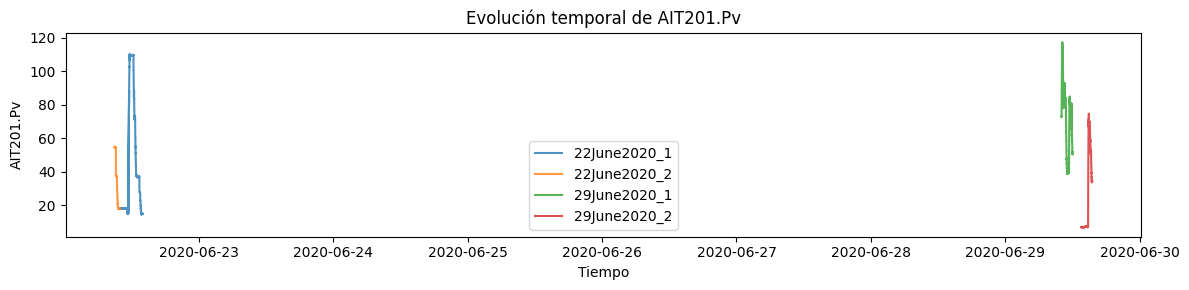

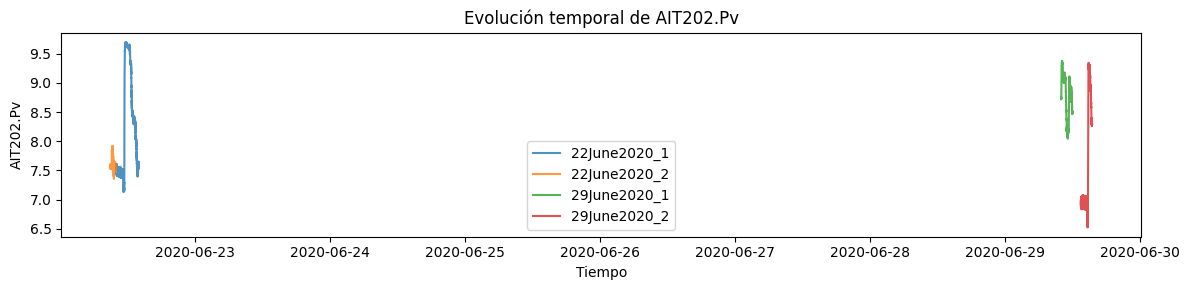

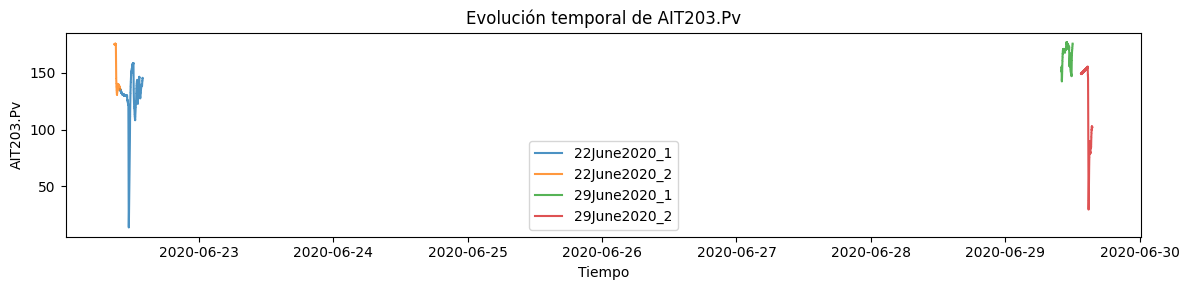

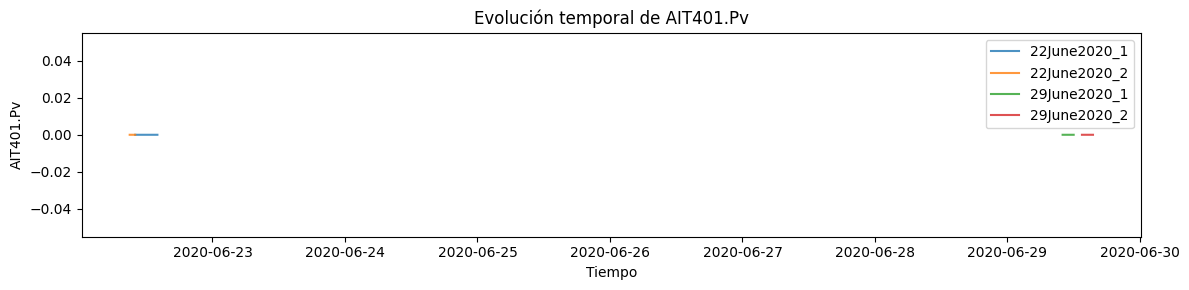

In [9]:
import matplotlib.pyplot as plt

example_pv = pv_cols[:4]  # puedes cambiar el número

for col in example_pv:
    plt.figure(figsize=(12, 3))
    for name, df in files_clean.items():
        plt.plot(df["t_stamp"], df[col], label=name, alpha=0.8)
    plt.title(f"Evolución temporal de {col}")
    plt.xlabel("Tiempo")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Frecuencia de estados discretos

In [10]:
for col in (status_cols + state_cols)[:6]:  # muestra algunas
    print(f"\n===== {col} =====")
    for name, df in files_clean.items():
        print(f"{name}:")
        print(df[col].value_counts(dropna=False).sort_index())


===== MV101.Status =====
22June2020_1:
MV101.Status
0       16
1    13582
2      802
Name: count, dtype: Int64
22June2020_2:
MV101.Status
1    3600
Name: count, dtype: Int64
29June2020_1:
MV101.Status
0      52
1    5829
2    1320
Name: count, dtype: Int64
29June2020_2:
MV101.Status
0         15
1       6714
2        471
<NA>       1
Name: count, dtype: Int64

===== MV201.Status =====
22June2020_1:
MV201.Status
0      63
1    8679
2    5658
Name: count, dtype: Int64
22June2020_2:
MV201.Status
0      16
1    2158
2    1426
Name: count, dtype: Int64
29June2020_1:
MV201.Status
0      28
1    1554
2    5619
Name: count, dtype: Int64
29June2020_2:
MV201.Status
0         24
1       4814
2       2362
<NA>       1
Name: count, dtype: Int64

===== MV301.Status =====
22June2020_1:
MV301.Status
0       43
1    14258
2       99
Name: count, dtype: Int64
22June2020_2:
MV301.Status
1    3600
Name: count, dtype: Int64
29June2020_1:
MV301.Status
1    7201
Name: count, dtype: Int64
29June2020_2:
MV301

## Corrección de fila problemática para 29June2020_2

Se encontró una fila en 29June2020_2 con todos los valores nulos, se eliminará.

In [11]:
for name, df in files_clean.items():
    bad_rows = df[df.isna().any(axis=1)]
    print(f"\n{name}: {len(bad_rows)} filas con NaN")
    if len(bad_rows) > 0:
        display(bad_rows.head())


22June2020_1: 0 filas con NaN

22June2020_2: 0 filas con NaN

29June2020_1: 0 filas con NaN

29June2020_2: 1 filas con NaN


,AIT201.Pv,AIT202.Pv,AIT203.Pv,AIT401.Pv,AIT402.Pv,AIT501.Pv,AIT502.Pv,AIT503.Pv,AIT504.Pv,DPIT301.Pv,...,P502.Status,P5_STATE,P601.Status,P602.Status,P6_STATE,PIT501.Pv,PIT502.Pv,PIT503.Pv,UV401.Status,t_stamp
7200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,<NA>,2020-06-29 15:30:00


In [12]:
files_clean["29June2020_2"] = files_clean["29June2020_2"].dropna().reset_index(drop=True)

In [13]:
for name, df in files_clean.items():
    print(name, df.isna().sum().sum())

22June2020_1 0
22June2020_2 0
29June2020_1 0
29June2020_2 0


## Evaluación de estabilidad inicial por sesión

A7 son arranques del sistemas, por tanto, se medirá si los primeros minutos son más volátiles.

Se evaluarán primero sensores clave:

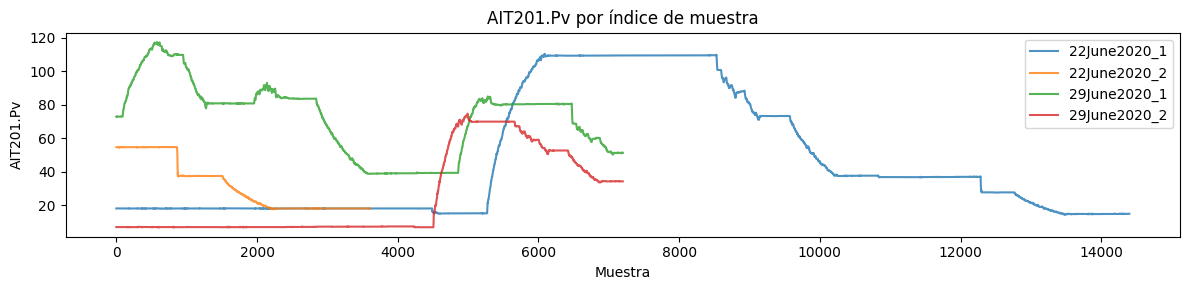

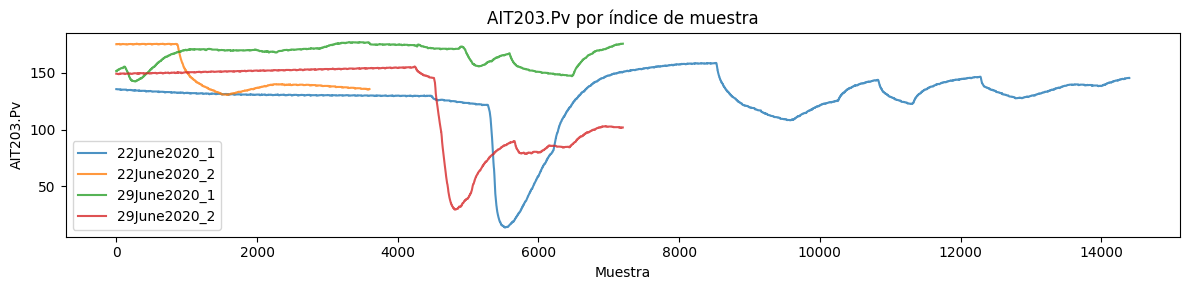

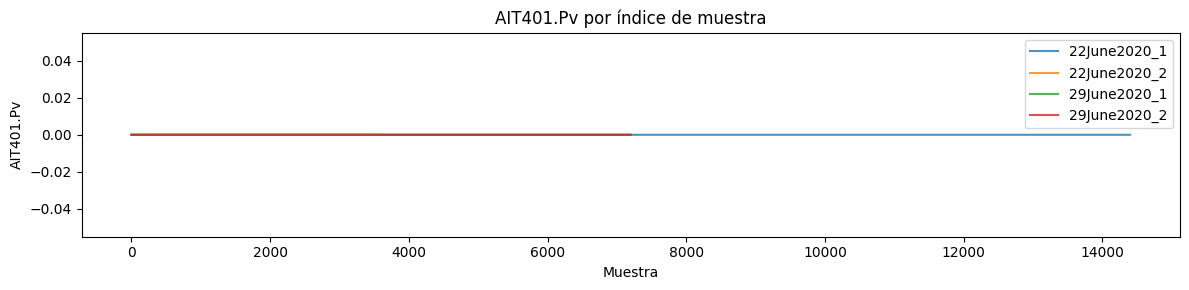

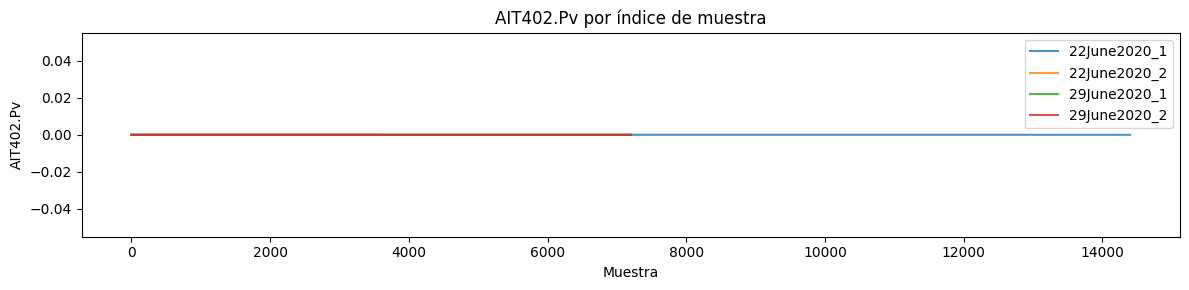

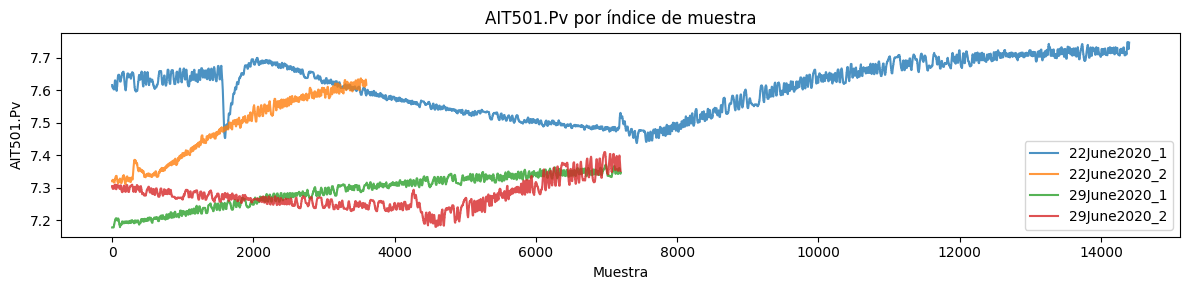

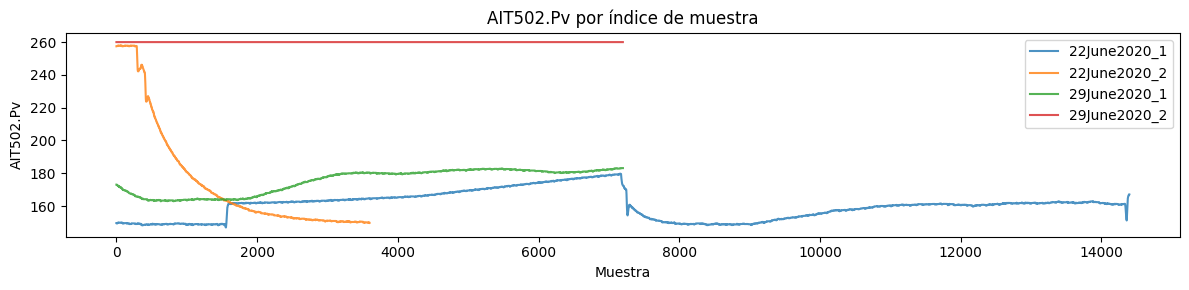

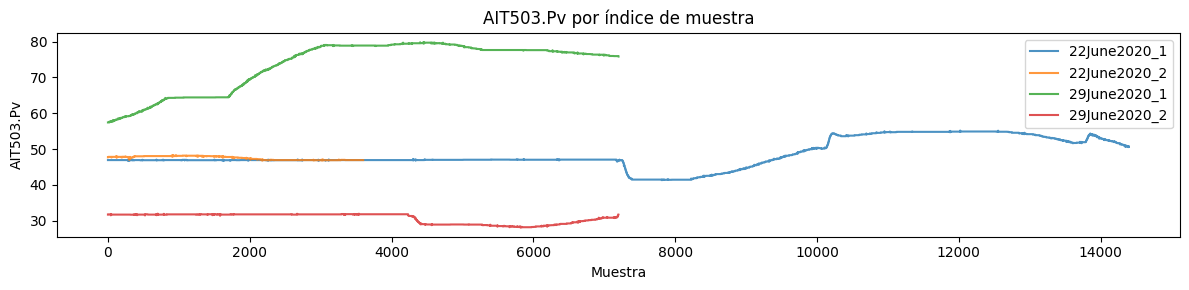

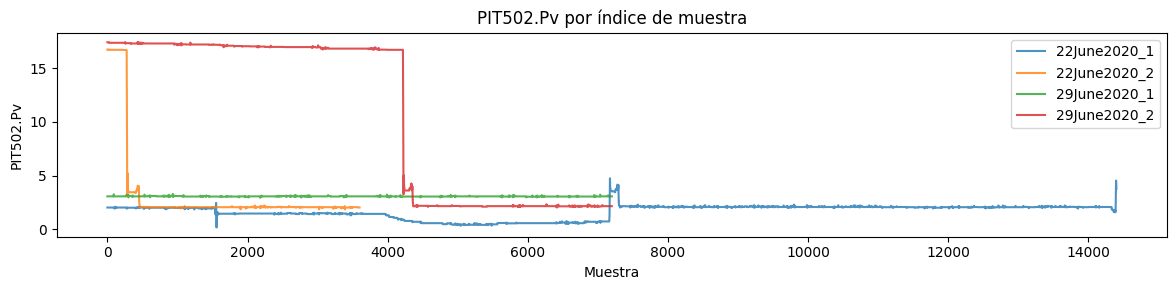

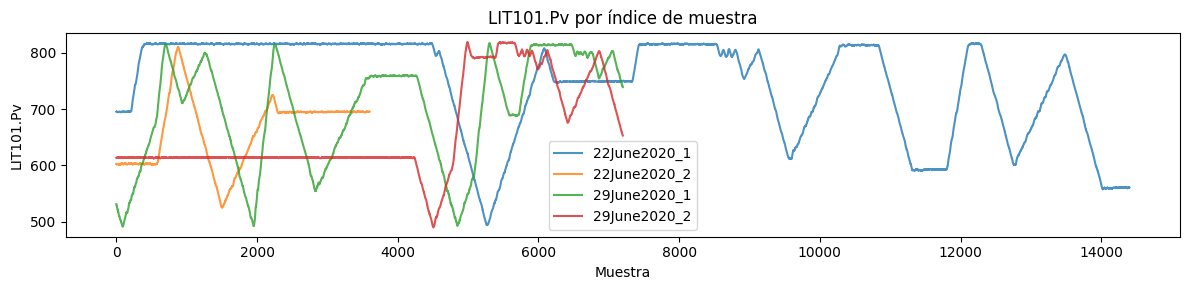

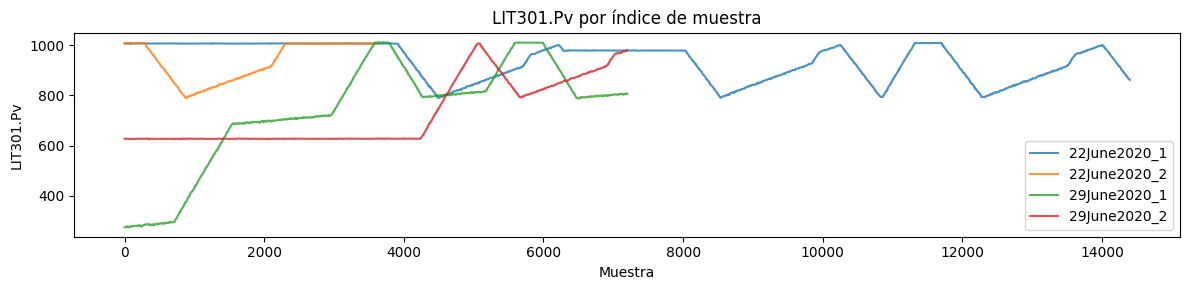

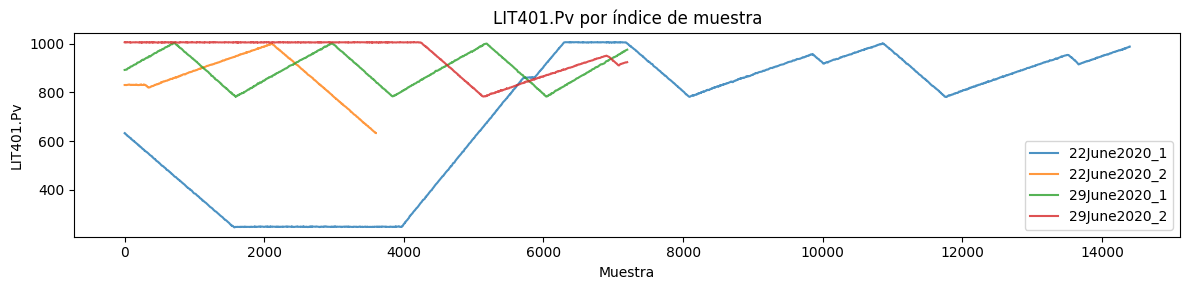

In [14]:
key_pv = ["AIT201.Pv", "AIT203.Pv", "AIT401.Pv", "AIT402.Pv", "AIT501.Pv", "AIT502.Pv", "AIT503.Pv", "PIT502.Pv", "LIT101.Pv", "LIT301.Pv", "LIT401.Pv"]

import matplotlib.pyplot as plt

for col in key_pv:
    plt.figure(figsize=(12,3))
    for name, df in files_clean.items():
        if col in df.columns:
            x = np.arange(len(df))
            plt.plot(x, df[col], label=name, alpha=0.8)
    plt.title(f"{col} por índice de muestra")
    plt.xlabel("Muestra")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

Ahora mediremos la variabilidad inicial contra el resto.

first_n se inicializa en 600 segundos (10 minutos).

In [15]:
def compare_initial_variability(df, cols, first_n=600):
    rows = []
    for col in cols:
        s = df[col].dropna()
        if len(s) > first_n + 10:
            init_std = s.iloc[:first_n].std()
            rest_std = s.iloc[first_n:].std()
            ratio = np.nan if rest_std == 0 else init_std / rest_std
            rows.append({
                "feature": col,
                "init_std": init_std,
                "rest_std": rest_std,
                "ratio_init_rest": ratio
            })
    return pd.DataFrame(rows).sort_values("ratio_init_rest", ascending=False)

for name, df in files_clean.items():
    print(f"\n===== {name} =====")
    display(compare_initial_variability(df, key_pv, first_n=600).head(15))


===== 22June2020_1 =====


,feature,init_std,rest_std,ratio_init_rest
8,LIT101.Pv,54.382700,86.081914,0.631755
4,AIT501.Pv,0.017662,0.081865,0.215742
10,LIT401.Pv,42.867835,284.353783,0.150755
5,AIT502.Pv,0.420308,8.177227,0.051400
7,PIT502.Pv,0.024143,0.639629,0.037745
1,AIT203.Pv,0.653455,25.529389,0.025596
6,AIT503.Pv,0.032274,3.980477,0.008108
9,LIT301.Pv,0.106097,70.637370,0.001502
0,AIT201.Pv,0.045991,36.273969,0.001268
2,AIT401.Pv,0.000000,0.000000,NaN



===== 22June2020_2 =====


,feature,init_std,rest_std,ratio_init_rest
7,PIT502.Pv,6.907238,0.025670,269.077200
5,AIT502.Pv,17.289042,14.508876,1.191618
9,LIT301.Pv,38.750382,79.589927,0.486875
6,AIT503.Pv,0.166775,0.524015,0.318264
4,AIT501.Pv,0.017443,0.083189,0.209682
10,LIT401.Pv,6.207589,97.447999,0.063702
8,LIT101.Pv,0.991404,59.540454,0.016651
1,AIT203.Pv,0.155849,12.020862,0.012965
0,AIT201.Pv,0.055559,11.663155,0.004764
2,AIT401.Pv,0.000000,0.000000,NaN



===== 29June2020_1 =====


,feature,init_std,rest_std,ratio_init_rest
7,PIT502.Pv,0.024872,0.026659,0.932936
0,AIT201.Pv,15.003837,20.832394,0.720217
8,LIT101.Pv,61.620932,89.110475,0.691512
1,AIT203.Pv,4.888346,8.034780,0.608398
10,LIT401.Pv,27.776044,63.430190,0.437899
5,AIT502.Pv,2.954698,7.216069,0.409461
6,AIT503.Pv,1.204388,5.560633,0.216592
4,AIT501.Pv,0.006860,0.042808,0.160259
9,LIT301.Pv,4.909440,166.221279,0.029536
2,AIT401.Pv,0.000000,0.000000,NaN



===== 29June2020_2 =====


,feature,init_std,rest_std,ratio_init_rest
4,AIT501.Pv,0.008821,0.043598,0.202331
6,AIT503.Pv,0.046731,1.400204,0.033374
1,AIT203.Pv,0.253332,37.776515,0.006706
7,PIT502.Pv,0.036449,7.366360,0.004948
9,LIT301.Pv,0.583679,130.136894,0.004485
10,LIT401.Pv,0.300313,72.050580,0.004168
8,LIT101.Pv,0.337277,84.049880,0.004013
0,AIT201.Pv,0.044301,24.994582,0.001772
2,AIT401.Pv,0.000000,0.000000,NaN
3,AIT402.Pv,0.000000,0.000000,NaN


## Perfilamiento por columna

Se creará una pequeña tabla resumen de todas las variables tanto discretas como continuas.

In [16]:
profile_rows = []

for col in feature_cols:
    col_type = (
        "continuous" if col in pv_cols
        else "discrete" if col in status_cols + state_cols
        else "other"
    )
    
    values = pd.concat([df[col] for df in files_clean.values()], axis=0)
    
    profile_rows.append({
        "feature": col,
        "type": col_type,
        "n_unique": values.nunique(dropna=True),
        "missing": values.isna().sum(),
        "is_constant": values.nunique(dropna=True) <= 1,
        "min": values.min() if col_type == "continuous" else None,
        "max": values.max() if col_type == "continuous" else None,
        "mean": values.mean() if col_type == "continuous" else None,
        "std": values.std() if col_type == "continuous" else None
    })

profile_df = pd.DataFrame(profile_rows).sort_values(["type", "feature"])
display(profile_df)

,feature,type,n_unique,missing,is_constant,min,max,mean,std
0,AIT201.Pv,continuous,1817,0,False,6.729044,117.405792,4.538645e+01,3.333202e+01
1,AIT202.Pv,continuous,5838,0,False,6.525122,9.695784,8.194726e+00,8.985818e-01
2,AIT203.Pv,continuous,2954,0,False,13.919508,177.108429,1.379827e+02,2.993334e+01
3,AIT401.Pv,continuous,1,0,True,0.000000,0.000000,0.000000e+00,0.000000e+00
4,AIT402.Pv,continuous,1,0,True,0.000000,0.000000,0.000000e+00,0.000000e+00
5,AIT501.Pv,continuous,1369,0,False,7.177519,7.747885,7.449547e+00,1.689963e-01
6,AIT502.Pv,continuous,1282,0,False,146.936676,260.000000,1.876159e+02,4.132093e+01
7,AIT503.Pv,continuous,613,0,False,28.101768,79.851320,4.998782e+01,1.498397e+01
8,AIT504.Pv,continuous,358,0,False,0.038452,101.473984,2.353729e+00,4.103129e+00
9,DPIT301.Pv,continuous,1125,0,False,0.016006,19.191370,9.576453e+00,6.394101e+00


Se identifican algunos sensores constantes, como AIT401.Pv o AIT402.Pv.

Esto no es un comportamiento físico real, es un sensor no activo en estas sesiones.

Esto ocurre en SWaT porque algunos sensores no se usan en todas las configuraciones del experimento.

In [17]:
constant_cols = profile_df.loc[profile_df["is_constant"], "feature"].tolist()
print("Columnas constantes:", constant_cols)

Columnas constantes: ['AIT401.Pv', 'AIT402.Pv', 'P102.Status', 'P202.Status', 'P204.Status', 'P206.Status', 'P302.Status', 'P402.Status', 'P403.Status', 'P404.Status', 'P502.Status']


In [18]:
feature_cols = [c for c in feature_cols if c not in constant_cols]

pv_cols = [c for c in pv_cols if c not in constant_cols]
status_cols = [c for c in status_cols if c not in constant_cols]
state_cols = [c for c in state_cols if c not in constant_cols]

## Observaciones importantes

* Se deben eliminar los sensores constantes como AIT401 Y AIT 402, puesto que para modelos, no aportan información y no cambian con el tiempo.

* Se debe eliminar el periodo de arranque puesto que se producen transitorios que no representan el régimen estacionario del proceso, las gráficas de AIT201, AIT 203, LIT101 y AIT502 lo demuestran. Se eliminarán los primeros 2 minutos iniciales, es decir, las primeras 120 muestras.

In [20]:
WARMUP = 120

files_trimmed = {
    name: df.iloc[WARMUP:].reset_index(drop=True)
    for name, df in files_clean.items()
}

In [23]:
constant_cols = profile_df.loc[profile_df["is_constant"], "feature"].tolist()

print("Eliminando columnas constantes:", constant_cols)

for name in files_clean:
    files_clean[name] = files_clean[name].drop(columns=constant_cols)

Eliminando columnas constantes: ['AIT401.Pv', 'AIT402.Pv', 'P102.Status', 'P202.Status', 'P204.Status', 'P206.Status', 'P302.Status', 'P402.Status', 'P403.Status', 'P404.Status', 'P502.Status']


In [24]:
pv_cols = [c for c in pv_cols if c not in constant_cols]
status_cols = [c for c in status_cols if c not in constant_cols]
state_cols = [c for c in state_cols if c not in constant_cols]
feature_cols = [c for c in feature_cols if c not in constant_cols]

## Matriz de correlación

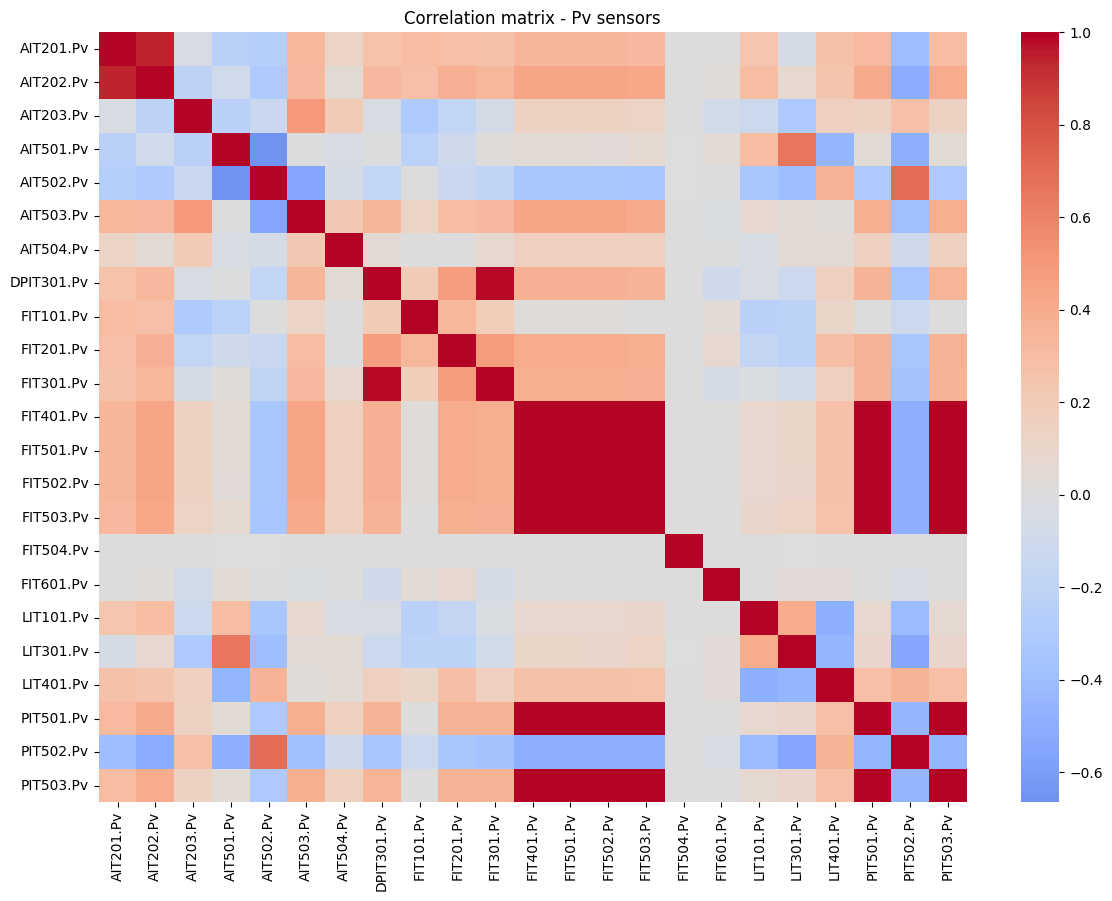

In [25]:
import seaborn as sns

train_df = pd.concat([
    files_trimmed["22June2020_1"],
    files_trimmed["22June2020_2"],
    files_trimmed["29June2020_1"],
    files_trimmed["29June2020_2"]
])

corr = train_df[pv_cols].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation matrix - Pv sensors")
plt.show()